#### 🗂️ Step-by-Step Instructions
#### 1. Data Loading and Initial Exploration
#### Import the necessary libraries.


In [22]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from collections import Counter


#### Load the dataset using Pandas.


In [3]:
df = pd.read_csv("netflix_titles.csv")

#### Display the first few rows to understand the structure.


In [16]:
df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,added_year,added_month
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,September
1,s2,TV Show,Blood & Water,Not Available,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,September


#### Check for null values and data types.

In [5]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

# 2. Data Cleaning

Convert date_added to datetime format.

Extract additional features like the year and month from

Handle missing values appropriately (e.g., fill,)

In [6]:
df["director"].fillna("Not Available", inplace=True)
df["cast"].fillna("Not Available", inplace=True)
df["country"].fillna("Unknown", inplace=True)



C:\Users\SC\AppData\Local\Temp\ipykernel_9652\2655169505.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["director"].fillna("Not Available", inplace=True)
C:\Users\SC\AppData\Local\Temp\ipykernel_9652\2655169505.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

Handle missing values appropriately (drop).


In [7]:
df.dropna(subset=["date_added","rating","duration"], inplace=True)

In [8]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

Extract additional features like the year and month from date_added.




In [15]:
df["date_added"] = df["date_added"].astype(str).str.strip()
df["date_added"] = pd.to_datetime(df["date_added"])

df["added_year"] = df["date_added"].dt.year
df['added_month'] = df['date_added'].dt.month_name()


### 3. Exploratory Data Analysis (EDA)


Examine the number of releases per year.

Determine the most frequent content ratings.

Explore the distribution of content duration.


##### Analyze the distribution of content types (Movies vs. TV Shows).


C:\Users\SC\AppData\Local\Temp\ipykernel_9652\1651679400.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, x= "type", palette="Set2" )


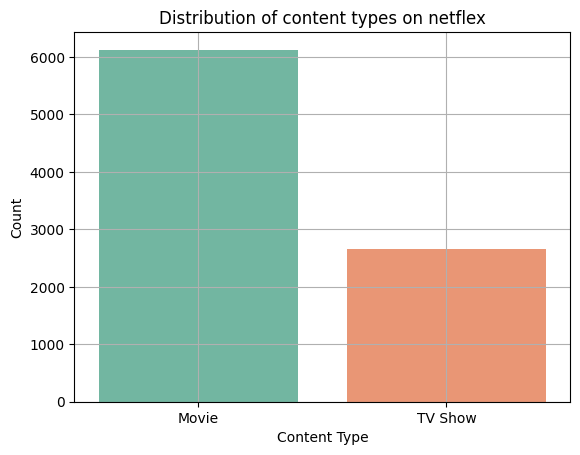

In [ ]:
sns.countplot(data = df, x= "type", palette="Set2" )
plt.title("Distribution of content types on netflex")
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.grid(True)
plt.show()

### Identify the top genres available on Netflix.


C:\Users\SC\AppData\Local\Temp\ipykernel_9652\1941605239.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=genre_df, x='Count', y='Genre', palette='coolwarm')  # Create a barplot


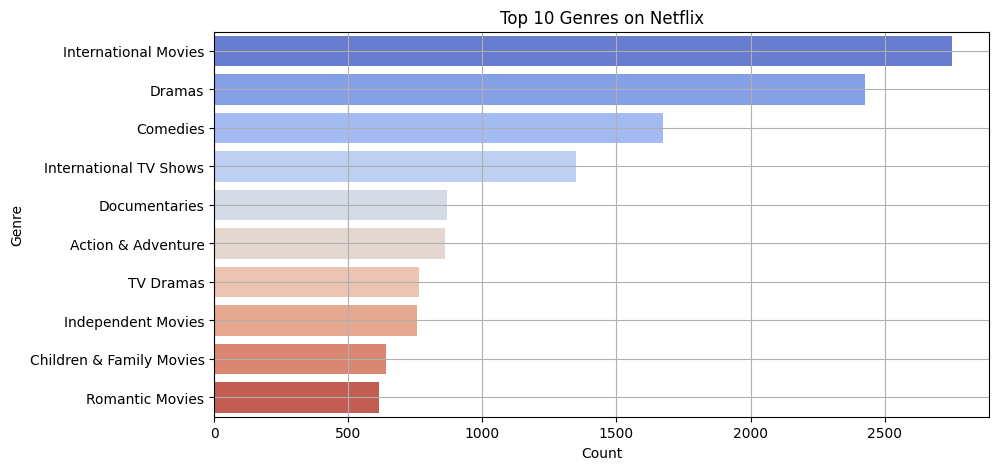

In [29]:

# Step 1: Split the 'listed_in' column (which contains genres separated by commas) into separate genres
# This will create a list of lists (each row becomes a list of genres)
all_genres = df['listed_in'].str.split(', ')

# Step 2: Flatten the list of lists into one single list of all genres
flat_genres = []
for sublist in all_genres:
    for genre in sublist:
        flat_genres.append(genre)

# Step 3: Count how many times each genre appears using Counter
genre_counts = Counter(flat_genres).most_common(10)  # Get top 10 genres

# Step 4: Convert the result into a DataFrame so it's easier to visualize
genre_df = pd.DataFrame(genre_counts, columns=['Genre', 'Count'])

# Step 5: Plot a bar chart to show the top 10 genres
plt.figure(figsize=(10, 5))  # Set the figure size
sns.barplot(data=genre_df, x='Count', y='Genre', palette='coolwarm')  # Create a barplot
plt.title('Top 10 Genres on Netflix')  # Set title
plt.xlabel('Count')  # X-axis label
plt.ylabel('Genre')  # Y-axis label
plt.grid()
plt.show()  # Display the plot


## Examine the number of releases per year.


In [37]:
# plt.figure(figsize=(30, 5))

# sns.countplot(data=df , x="release_year" , palette="viridis", order=sorted(df["release_year"].unique()))
# # plt.xticks(45)
# plt.title("Number of movies relase per year ")
# plt.xlabel("Relase year")
# plt.ylabel("Counts")
# plt.grid()
# plt.show()

## ✅ 4. Most Frequent Content Ratings


C:\Users\SC\AppData\Local\Temp\ipykernel_9652\361665524.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df , x="rating", order=df["rating"].value_counts().index[:10],palette="pastel")


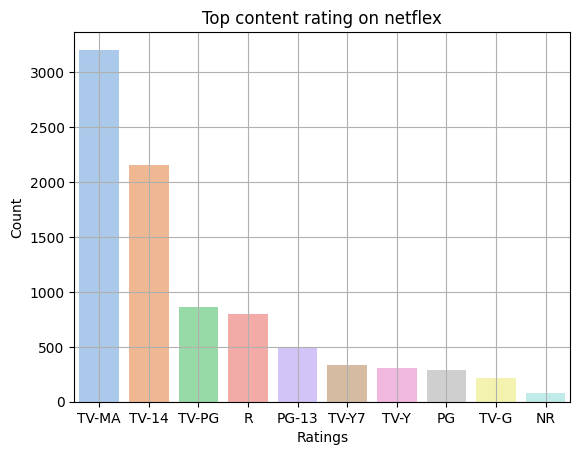

In [38]:
sns.countplot(data=df , x="rating", order=df["rating"].value_counts().index[:10],palette="pastel")
plt.title("Top content rating on netflex")
plt.xlabel("Ratings")
plt.ylabel("Count")
plt.grid()
plt.show()

## ✅ 5. Distribution of Content Duration


<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
C:\Users\SC\AppData\Local\Temp\ipykernel_9652\1664915617.py:3: SyntaxWarning: invalid escape sequence '\d'
  movies['duration_int'] = movies['duration'].str.extract('(\d+)').astype(float)


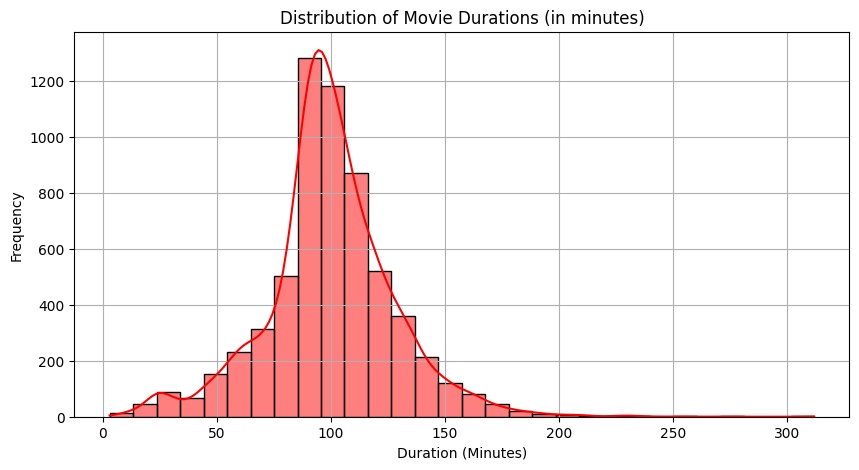

In [46]:
# Filter movies and extract numeric duration
movies = df[df['type'] == 'Movie'].copy()
movies['duration_int'] = movies['duration'].str.extract('(\d+)').astype(float)

plt.figure(figsize=(10, 5))
sns.histplot(movies['duration_int'], bins=30, kde=True, color='red')
plt.title('Distribution of Movie Durations (in minutes)')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Frequency')
plt.grid()
plt.show()



## 🎨 4. Visualization

## Create bar charts for content types and ratings.
